# Fit-fraction averages across bins and samples

This notebook loads every configured dataset × bin × emission-line × fit-limit result, applies a group-specific fit-limit selection, converts s0 from pc to arcsec, and makes the two requested comparisons. Multiple limits are averaged; one limit is used directly without averaging.

1. emission lines compared across binning levels;
2. MUSE, MUSE trim, and KPNO compared with emission lines on the x-axis.

All reusable logic is in fit_fraction_latex_tools.py. Normally you only need to edit the configuration cells below.


In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

ROOT = Path.cwd()
sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / "py_modules"))

from pipeline_config import MAPS_DIR, FIGS_DIR
import results_comp
import fit_fraction_latex_tools as ffa
import importlib
ffa = importlib.reload(ffa)

sns.set_context("talk")


## 1. Configure all input result grids

The filename templates reproduce the supplied notebooks. MUSE sulfur is given the plotting key S2 because it is [S III], while KPNO S is [S II].


In [2]:
FIT_LIMITS = (0.3, 0.4, 0.5, 0.6, 0.7, 0.8)
FIT_LIMITS_BY_GROUP = {
    # Two or more limits -> mean plus full uncertainty envelope.
    "MUSE": (0.5),
    "MUSE trim": (0.4, 0.5, 0.6),
    # One limit -> use that fit directly, without averaging.
    "KPNO": (0.4,0.5,0.6),
}

DATASET_CONFIGS = [
    {
        "group": "MUSE",
        "dataset_prefix": "MUSE-M42",
        "bin_levels": (0, 1, 2, 3, 4),
        "line_order": ("N", "S2", "Ar", "H", "O"),
        "file_line_ids": {"S2": "S"},
        "filename_template": "{dataset_prefix}-{file_line}-bin{bin}_{fit_tag}",
    },
    {
        "group": "MUSE trim",
        "dataset_prefix": "MUSE-M42",
        "bin_levels": (2,),
        "line_order": ("N", "H", "O"),
        "filename_template": "{dataset_prefix}-{file_line}-bin{bin}_trim_{fit_tag}",
    },
    {
        "group": "KPNO",
        "dataset_prefix": "KPNO-M42",
        "bin_levels": (0,),
        "line_order": ("N", "S", "H", "O"),
        "filename_template": "{dataset_prefix}-{file_line}-bin{bin}_{fit_tag}",
    },
]

LINE_LABELS = {
    "S": r"[S II]",
    "N": r"[N II]",
    "S2": r"[S III]",
    "Ar": r"[Ar III]",
    "H": r"H$\alpha$",
    "O": r"[O III]",
}

PARAM_LABELS_ARCSEC = {
    "sig2": r"$\sigma^2$ [km$^2$ s$^{-2}$]",
    "r0": r"$r_0$ [pc]",
    "m": r"$m$",
    "noise": r"$B_\mathrm{noise}$ [km$^2$ s$^{-2}$]",
    "s0": r"$s_0$ [arcsec]",
}

PARAM_YLIMS_ARCSEC = {
    "sig2": (0, 20),
    "r0": (0, 0.15),
    "m": (0.5, 1.5),
    "noise": (-1, 15),
    "s0": (0, 4),
}

SAVE_FIGURES = False


## 2. Preview and load every fraction result

Use on_error="raise" when the grid must be complete. The current "warn" setting skips unavailable combinations and records them in failures.


In [3]:
samples = ffa.build_fraction_sample_grid(DATASET_CONFIGS, FIT_LIMITS)
sample_table = pd.DataFrame(samples)[
    ["group", "bin", "line", "fit_limit", "file_name"]
]
print(f"Configured {len(sample_table)} result files")
display(sample_table.head(12))


Configured 192 result files


,group,bin,line,fit_limit,file_name
0,MUSE,0,N,0.3,MUSE-M42-N-bin0_03
1,MUSE,0,N,0.4,MUSE-M42-N-bin0_04
2,MUSE,0,N,0.5,MUSE-M42-N-bin0_05
3,MUSE,0,N,0.6,MUSE-M42-N-bin0_06
4,MUSE,0,N,0.7,MUSE-M42-N-bin0_07
5,MUSE,0,N,0.8,MUSE-M42-N-bin0_08
6,MUSE,0,S2,0.3,MUSE-M42-S-bin0_03
7,MUSE,0,S2,0.4,MUSE-M42-S-bin0_04
8,MUSE,0,S2,0.5,MUSE-M42-S-bin0_05
9,MUSE,0,S2,0.6,MUSE-M42-S-bin0_06


In [4]:
all_fraction_results, failures = ffa.load_multi_line_bin_fraction_results(
    results_comp,
    MAPS_DIR,
    dataset_configs=DATASET_CONFIGS,
    fit_limits=FIT_LIMITS,
    read_header=True,
    on_error="warn",
    return_failures=True,
)

print(f"Loaded: {len(all_fraction_results)}")
print(f"Unavailable: {len(failures)}")

if failures:
    display(pd.DataFrame(failures)[["file_name", "error"]])


Loaded: 192
Unavailable: 0


## 3. Optional: inspect fraction dependence before averaging

This example compares all fractions for MUSE bin 2. Change RAW_GROUP and RAW_BIN to inspect another sample/bin.


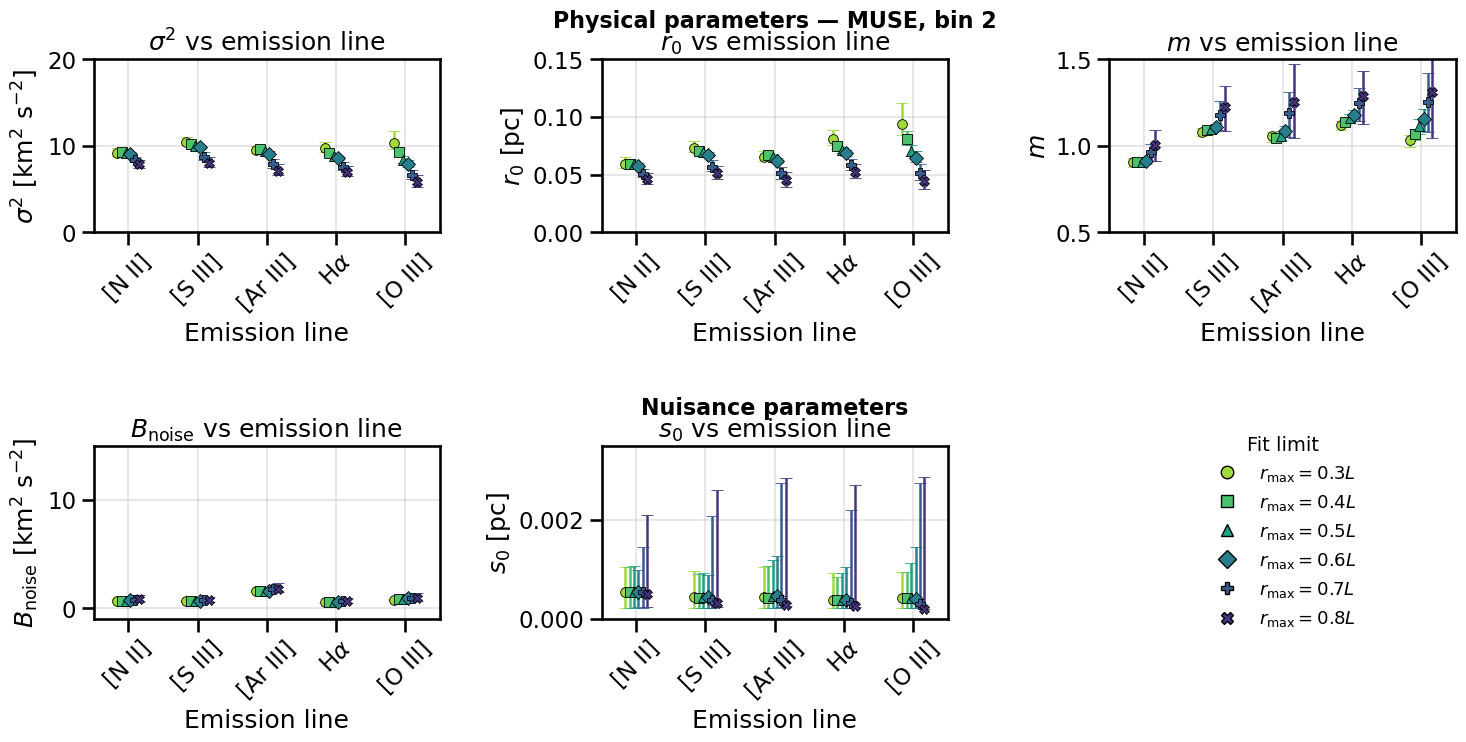

In [5]:
RAW_GROUP = "MUSE"
RAW_BIN = 2

raw_example = ffa.select_results(
    all_fraction_results,
    group=RAW_GROUP,
    bin=RAW_BIN,
)
fraction_labels = tuple(
    rf"$r_\mathrm{{max}} = {value:.1f}L$"
    for value in FIT_LIMITS
)

if raw_example:
    fig_raw, axes_raw = ffa.plot_param_grid_lines_as_x(
        raw_example,
        line_order=("N", "S2", "Ar", "H", "O"),
        group_order=fraction_labels,
        group_key="fit_limit_label",
        line_labels=LINE_LABELS,
        param_ylims={
            "sig2": (0, 20),
            "r0": (0, 0.15),
            "m": (0.5, 1.5),
            "noise": (-1, 15),
            "s0": (0, 0.0035),
        },
        row_titles=(f"Physical parameters — {RAW_GROUP}, bin {RAW_BIN}",
                    "Nuisance parameters"),
        color_palette="viridis",
        jitter=0.16,
        legend_title="Fit limit",
        save=SAVE_FIGURES,
        savepath=FIGS_DIR / f"fit_limits_{RAW_GROUP}_bin{RAW_BIN}.pdf",
    )
    plt.show()
else:
    print("No results are available for the requested raw comparison.")


## 4. Select or average group-specific fit limits

Each group uses its own selection from FIT_LIMITS_BY_GROUP. Two or more limits produce the mean with the full asymmetric envelope. A single limit is passed through unchanged and is not averaged.


In [6]:
selected_results_pc = ffa.select_or_average_fit_results(
    all_fraction_results,
    fit_limits_by_group=FIT_LIMITS_BY_GROUP,
    group_keys=("group", "bin", "line"),
)

selected_table_pc = ffa.results_to_dataframe(selected_results_pc)
print(f"Created {len(selected_results_pc)} selected/averaged line results")
display(selected_table_pc.head(15))


Created 32 selected/averaged line results


,group,bin,line,fit_limit,fit_limits_used,selection_mode,parameter,value,err_lower,err_upper,lower_limit,upper_limit,n_samples
0,MUSE,0,N,0.5,"(0.5,)",single,sig2,9.207837,0.299163,0.343767,8.908674,9.551604,1
1,MUSE,0,N,0.5,"(0.5,)",single,r0,0.061487,0.003369,0.004531,0.058118,0.066018,1
2,MUSE,0,N,0.5,"(0.5,)",single,m,0.883699,0.027070,0.030241,0.856630,0.913941,1
3,MUSE,0,N,0.5,"(0.5,)",single,noise,3.948915,0.052950,0.116988,3.895965,4.065903,1
4,MUSE,0,N,0.5,"(0.5,)",single,s0,0.000199,-0.000002,0.000234,0.000201,0.000433,1
5,MUSE,0,S2,0.5,"(0.5,)",single,sig2,9.736010,0.260264,0.312340,9.475747,10.048351,1
6,MUSE,0,S2,0.5,"(0.5,)",single,r0,0.070916,0.003010,0.003668,0.067905,0.074583,1
7,MUSE,0,S2,0.5,"(0.5,)",single,m,1.102191,0.029610,0.030569,1.072581,1.132760,1
8,MUSE,0,S2,0.5,"(0.5,)",single,noise,3.194414,0.037558,0.070798,3.156856,3.265212,1
9,MUSE,0,S2,0.5,"(0.5,)",single,s0,0.000199,-0.000003,0.000341,0.000202,0.000540,1


## 5. Convert selected results' s0 from pc to arcsec

This preserves the central value and both asymmetric uncertainties. The conversion is s0_arcsec = s0_pc × 2.35 / PC, using each result's metadata.


In [7]:
selected_results = ffa.convert_s0_pc_to_arcsec(
    selected_results_pc,
    arcsec_per_pixel=2.35,
    copy=True,
)

selected_table = ffa.results_to_dataframe(selected_results)
display(selected_table.head(15))


,group,bin,line,fit_limit,fit_limits_used,selection_mode,parameter,value,err_lower,err_upper,lower_limit,upper_limit,n_samples
0,MUSE,0,N,0.5,"(0.5,)",single,sig2,9.207837,0.299163,0.343767,8.908674,9.551604,1
1,MUSE,0,N,0.5,"(0.5,)",single,r0,0.061487,0.003369,0.004531,0.058118,0.066018,1
2,MUSE,0,N,0.5,"(0.5,)",single,m,0.883699,0.027070,0.030241,0.856630,0.913941,1
3,MUSE,0,N,0.5,"(0.5,)",single,noise,3.948915,0.052950,0.116988,3.895965,4.065903,1
4,MUSE,0,N,0.5,"(0.5,)",single,s0,0.235000,0.000000,0.277071,0.235000,0.512071,1
5,MUSE,0,S2,0.5,"(0.5,)",single,sig2,9.736010,0.260264,0.312340,9.475747,10.048351,1
6,MUSE,0,S2,0.5,"(0.5,)",single,r0,0.070916,0.003010,0.003668,0.067905,0.074583,1
7,MUSE,0,S2,0.5,"(0.5,)",single,m,1.102191,0.029610,0.030569,1.072581,1.132760,1
8,MUSE,0,S2,0.5,"(0.5,)",single,noise,3.194414,0.037558,0.070798,3.156856,3.265212,1
9,MUSE,0,S2,0.5,"(0.5,)",single,s0,0.235000,0.000000,0.402876,0.235000,0.637876,1


## 6. Compare the selected MUSE results across binning levels


In [8]:
muse_selected = ffa.select_results(selected_results, group="MUSE")
available_muse_bins = tuple(sorted({entry["bin"] for entry in muse_selected}))
bin_tick_labels = {
    value: "$" + r"{} \times {}$".format(2**value, 2**value)
    for value in available_muse_bins
}



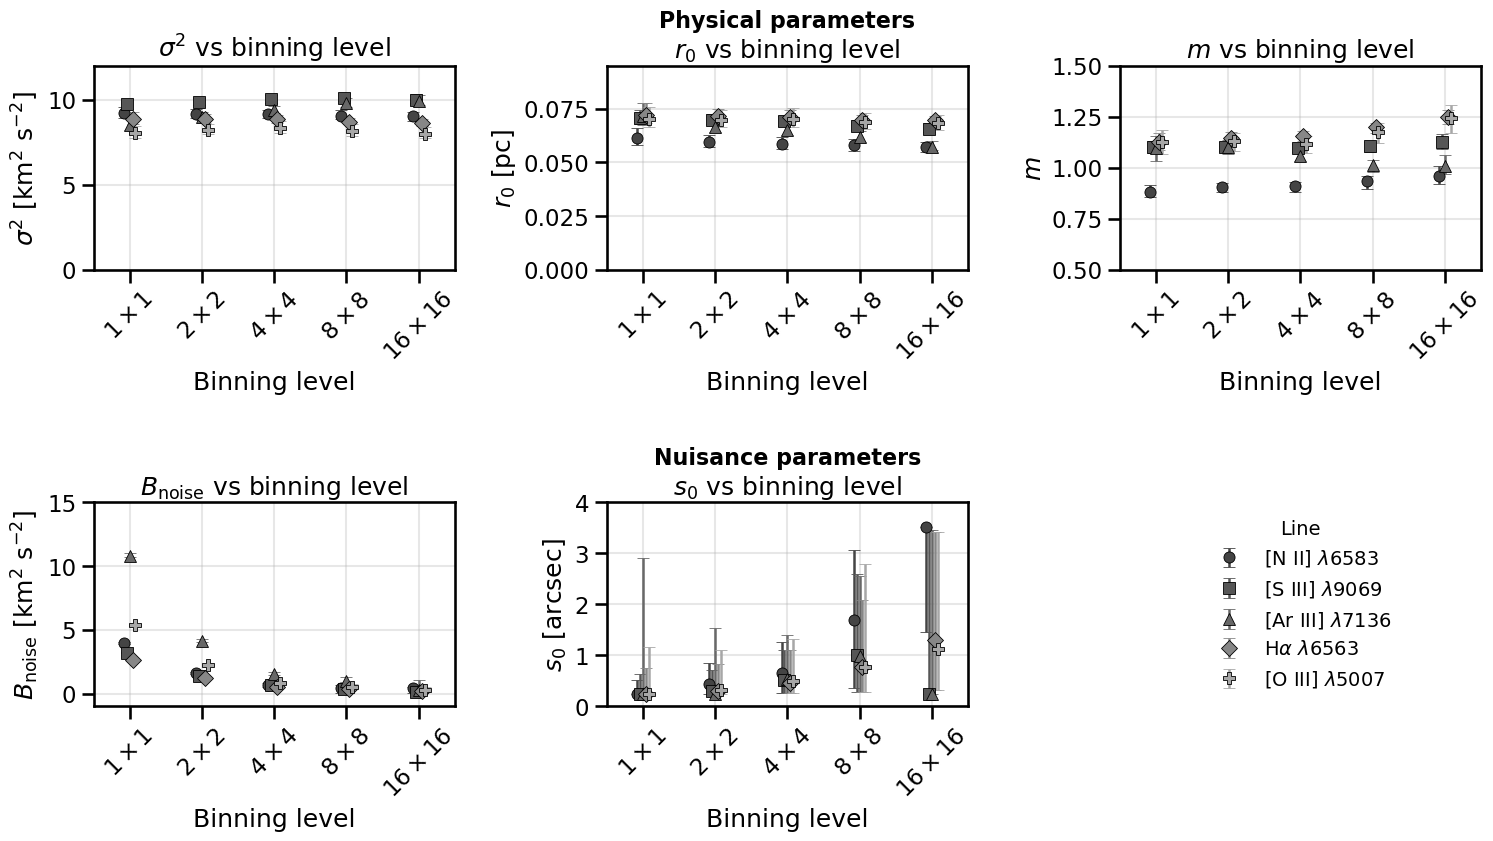

In [21]:
line_legend_labels = {
    "H": r"H$\alpha$ $\lambda$6563",
    "N": r"[N II] $\lambda$6583",
    "O": r"[O III] $\lambda$5007",
    "S2": r"[S III] $\lambda$9069",
    "Ar": r"[Ar III] $\lambda$7136",
}

fig_bins, axes_bins = ffa.plot_param_grid_lines_bins(
    muse_selected,
    group="MUSE",
    line_order=("N", "S2", "Ar", "H", "O"),
    bin_levels=available_muse_bins,
    xtick_labels=bin_tick_labels,
    line_legend_labels=line_legend_labels,
    param_labels=PARAM_LABELS_ARCSEC,
    param_ylims={
    "sig2": (0, 12),
    "r0": (0, 0.095),
    "m": (0.5, 1.5),
    "noise": (-1, 15),
    "s0": (0, 4),
    },
    row_titles=(
        "Physical parameters",
        "Nuisance parameters",
    ),
    figsize=(15, 9),
    markersize=8,
    legend_fontsize=14,
    jitter=0.08,
    save=True,
    savepath=FIGS_DIR / "fit_fraction_average_by_bin.pdf",
)

for ax in axes_bins[:5]:
    ax.set_box_aspect(None)
    ax.set_aspect("auto")

fig_bins.subplots_adjust(
    left=0.065,
    right=0.99,
    wspace=0.42,
)

plt.show()

## 7. Compare MUSE, MUSE trim, and KPNO by emission line

The selected comparison follows the supplied notebooks: MUSE bin 2, MUSE trim bin 2, and KPNO bin 0. Edit SAMPLE_BIN if you want a different representative bin.


In [10]:
SAMPLE_BIN = {
    "MUSE": 2,
    "MUSE trim": 2,
    "KPNO": 0,
}

sample_selected = [
    entry
    for entry in selected_results
    if entry.get("bin") == SAMPLE_BIN.get(entry.get("group"))
]


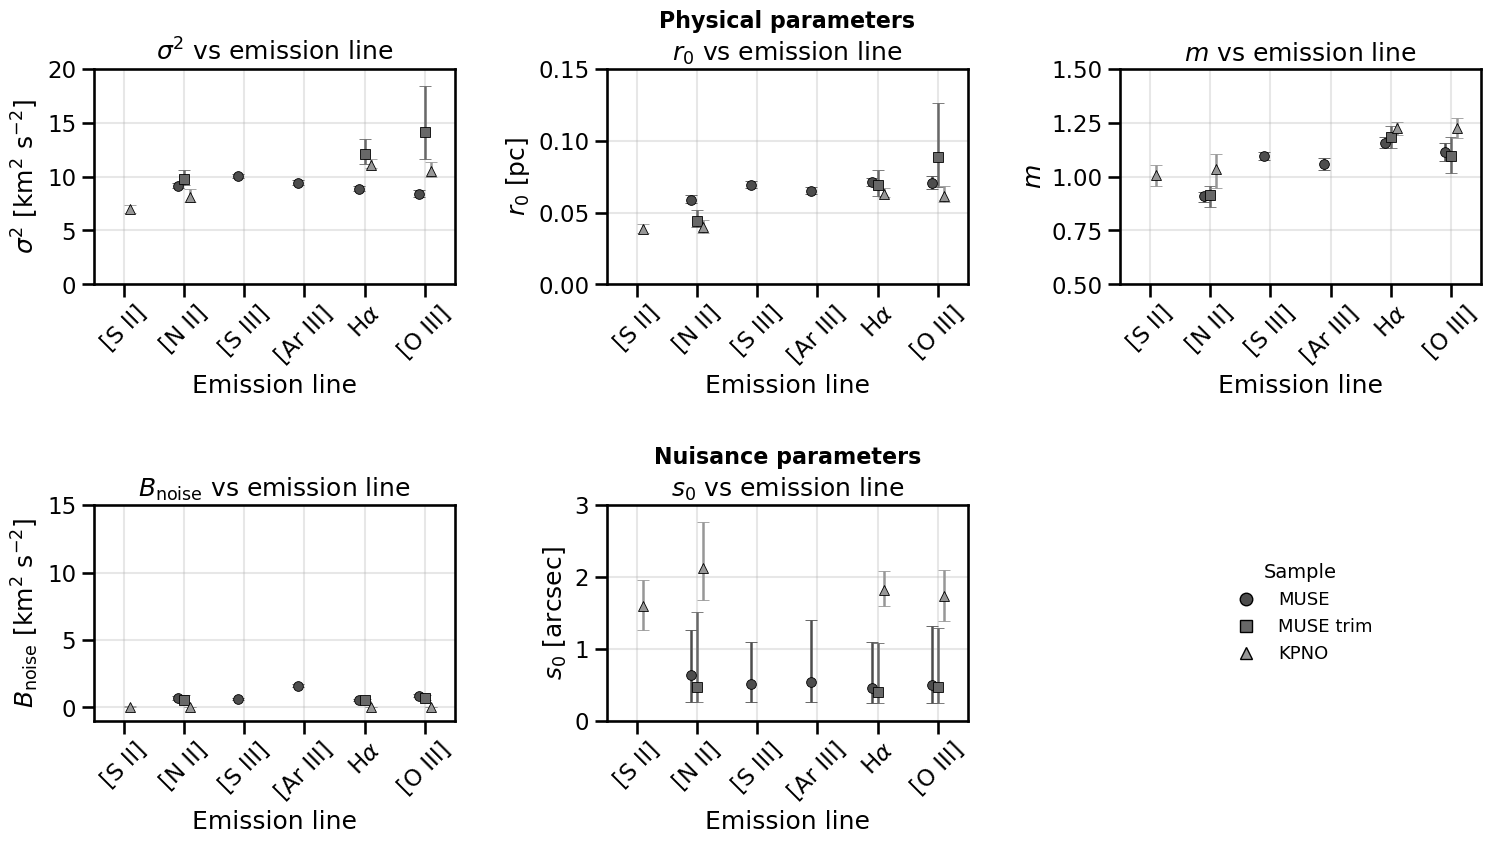

In [22]:
fig_samples, axes_samples = ffa.plot_param_grid_lines_as_x(
    sample_selected,
    line_order=("S", "N", "S2", "Ar", "H", "O"),
    group_order=("MUSE", "MUSE trim", "KPNO"),
    group_key="group",
    line_labels=LINE_LABELS,
    param_labels=PARAM_LABELS_ARCSEC,
    param_ylims=  {
    "sig2": (0, 20),
    "r0": (0, 0.15),
    "m": (0.5, 1.5),
    "noise": (-1, 15),
    "s0": (0, 3),
},
    row_titles=(
        "Physical parameters",
        "Nuisance parameters",
    ),
    row_title_fontsize=16,
    figsize=(15, 9),
    jitter=0.10,
    save=True,
    savepath=FIGS_DIR / "fit_fraction_average_by_sample.pdf",
)

for ax in axes_samples[:5]:
    ax.set_box_aspect(None)
    ax.set_aspect("auto")

fig_samples.subplots_adjust(
    left=0.065,
    right=0.99,
    wspace=0.42,
)

plt.show()

## 8. LaTeX table row for a chosen sample

Choose the group, bin, emission line, and fit limits below. Multiple limits are averaged with the full uncertainty envelope; one limit is used directly without averaging. This section deliberately uses the pc results because the derived LaTeX columns convert s0 to arcsec themselves.

Examples: MUSE uses bins 0–4; MUSE trim uses bin 2; KPNO uses bin 0. Available line keys are defined in DATASET_CONFIGS.


In [18]:
TABLE_SELECTION = {
    "group": "KPNO",
    "bin": 0,
    "line": "O",
    # Multiple values -> average; one value, e.g. (0.5,), -> direct fit.
    "fit_limits": (0.4,0.5,0.6),
}

table_group_results_pc = ffa.select_or_average_fit_results(
    all_fraction_results,
    fit_limits_by_group={
        TABLE_SELECTION["group"]: TABLE_SELECTION["fit_limits"]
    },
    group_keys=("group", "bin", "line"),
)

table_result_pc = ffa.get_fit_result(
    table_group_results_pc,
    group=TABLE_SELECTION["group"],
    bin_level=TABLE_SELECTION["bin"],
    line=TABLE_SELECTION["line"],
)

ffa.print_fit_summary_row(table_result_pc)


10.48\PM{0.88}{0.56} & 0.062\PM{0.007}{0.004} & 1.23\PM{0.04}{0.05} & 0.022\PM{0.005}{0.007} & 1.74\PM{0.36}{0.35} & 31.03 & 0.0239 & 0.017


'10.48\\PM{0.88}{0.56} & 0.062\\PM{0.007}{0.004} & 1.23\\PM{0.04}{0.05} & 0.022\\PM{0.005}{0.007} & 1.74\\PM{0.36}{0.35} & 31.03 & 0.0239 & 0.017'

In [13]:
for index in (0,1,2,3,4):
    TABLE_SELECTION = {
        "group": "MUSE",
        "bin": index,
        "line": "H",
        # Multiple values -> average; one value, e.g. (0.5,), -> direct fit.
        "fit_limits": (0.4,0.5,0.6),
    }
    
    table_group_results_pc = ffa.select_or_average_fit_results(
        all_fraction_results,
        fit_limits_by_group={
            TABLE_SELECTION["group"]: TABLE_SELECTION["fit_limits"]
        },
        group_keys=("group", "bin", "line"),
    )
    
    table_result_pc = ffa.get_fit_result(
        table_group_results_pc,
        group=TABLE_SELECTION["group"],
        bin_level=TABLE_SELECTION["bin"],
        line=TABLE_SELECTION["line"],
    )
    
    ffa.print_fit_summary_row(table_result_pc)

8.94\PM{1.18}{0.65} & 0.073\PM{0.015}{0.008} & 1.13\PM{0.07}{0.08} & 2.614\PM{0.106}{0.067} & 0.24\PM{0.67}{0.00} & 2.61 & 0.0027 & 0.005
8.91\PM{0.67}{0.51} & 0.072\PM{0.008}{0.006} & 1.15\PM{0.05}{0.04} & 1.222\PM{0.081}{0.039} & 0.30\PM{0.57}{0.06} & 3.82 & 0.0036 & 0.011
8.88\PM{0.61}{0.50} & 0.072\PM{0.007}{0.006} & 1.16\PM{0.05}{0.04} & 0.549\PM{0.098}{0.051} & 0.46\PM{0.78}{0.20} & 5.69 & 0.0054 & 0.022
8.71\PM{0.53}{0.41} & 0.070\PM{0.005}{0.005} & 1.20\PM{0.05}{0.05} & 0.332\PM{0.160}{0.083} & 0.79\PM{1.59}{0.52} & 7.25 & 0.0096 & 0.046
8.65\PM{0.50}{0.44} & 0.070\PM{0.005}{0.004} & 1.25\PM{0.07}{0.06} & 0.227\PM{0.201}{0.197} & 1.78\PM{1.66}{1.48} & 8.74 & 0.0217 & 0.091


### Optional: print every available emission line for that group and bin


In [14]:
latex_rows = ffa.format_fit_summary_rows(
    table_group_results_pc,
    group=TABLE_SELECTION["group"],
    bin_level=TABLE_SELECTION["bin"],
    line_order=next(
        config["line_order"]
        for config in DATASET_CONFIGS
        if config["group"] == TABLE_SELECTION["group"]
    ),
    include_identifiers=True,
    line_labels=LINE_LABELS,
    row_terminator=True,
)

print("\n".join(latex_rows))


MUSE & 4 & [N II] & 0.4,0.5,0.6 & 8.98\PM{0.31}{0.37} & 0.057\PM{0.003}{0.003} & 0.96\PM{0.05}{0.04} & 0.291\PM{0.214}{0.291} & 2.86\PM{0.67}{1.48} & 7.85 & 0.0428 & 0.112 \\
MUSE & 4 & [S III] & 0.4,0.5,0.6 & 9.99\PM{0.45}{0.28} & 0.065\PM{0.004}{0.002} & 1.13\PM{0.05}{0.04} & 0.274\PM{0.395}{0.202} & 1.20\PM{2.26}{0.97} & 8.54 & 0.0155 & 0.097 \\
MUSE & 4 & [Ar III] & 0.4,0.5,0.6 & 9.87\PM{0.66}{0.60} & 0.057\PM{0.005}{0.004} & 1.02\PM{0.10}{0.07} & 0.397\PM{0.821}{0.278} & 0.66\PM{2.80}{0.42} & 7.05 & 0.0098 & 0.112 \\
MUSE & 4 & H$\alpha$ & 0.4,0.5,0.6 & 8.65\PM{0.50}{0.44} & 0.070\PM{0.005}{0.004} & 1.25\PM{0.07}{0.06} & 0.227\PM{0.201}{0.197} & 1.78\PM{1.66}{1.48} & 8.74 & 0.0217 & 0.091 \\
MUSE & 4 & [O III] & 0.4,0.5,0.6 & 8.10\PM{0.85}{0.79} & 0.069\PM{0.009}{0.008} & 1.24\PM{0.15}{0.10} & 0.336\PM{0.306}{0.268} & 1.71\PM{1.74}{1.40} & 6.95 & 0.0209 & 0.092 \\


## 9. Optional export of the selected/averaged values


In [15]:
OUTPUT_TABLE = ROOT / "fit_fraction_selected_results.csv"
selected_table.to_csv(OUTPUT_TABLE, index=False)
print(f"Saved table to {OUTPUT_TABLE}")


Saved table to C:\Users\javas\Dropbox\GitHub\VIENTO\structure_function_analysis\MUSE_orion\MUSE_orion_global_mask\fit_fraction_selected_results.csv
